# Estratégia 5 — Multi-Camada: Combinando as 4 Estratégias
**Competição de Carteira de Investimentos 2026 — PPGOLD/UFPR**

---
## Arquitetura da Estratégia

Nenhuma estratégia individual captura toda a realidade do mercado. Esta abordagem funde os melhores elementos de cada metodologia em 5 camadas sequenciais e complementares:

```
┌─────────────────────────────────────────────────────────────────┐
│  CAMADA 1 — QUALIDADE (Piotroski F-Score)                       │
│  Filtra empresas fundamentalmente saudáveis (F-Score ≥ 6)       │
│  Garantia: ROE+, Margem+, Dívida controlada, Eficiência         │
├─────────────────────────────────────────────────────────────────┤
│  CAMADA 2 — VALUATION + RENTABILIDADE (EV/EBITDA + FF5)         │
│  Score Composto: EV/EBITDA + HML (B/M) + RMW (ROE) + CMA        │
│  Identifica: bem-precificadas E lucrativas                      │
├─────────────────────────────────────────────────────────────────┤
│  CAMADA 3 — TIMING: MOMENTUM (12-1)                             │
│  Confirma tendência de alta — evita value traps                 │
│  Penaliza: ativos ainda em queda mesmo sendo baratos            │
├─────────────────────────────────────────────────────────────────┤
│  CAMADA 4 — DIVERSIFICAÇÃO (Deduplicação por Empresa/Setor)     │
│  Uma empresa = um ativo: elimina ON+PN da mesma empresa         │
│  Impõe descorrelação real entre os 4 ativos finais              │
├─────────────────────────────────────────────────────────────────┤
│  CAMADA 5 — PONDERAÇÃO ÓTIMA (Markowitz + Combinatória)         │
│  C(top12, 4) = combinações → Maior Índice de Sharpe absoluto    │
│  Resultado: Exatamente 4 ativos de empresas distintas           │
└─────────────────────────────────────────────────────────────────┘
```

### Por que esta ordem?

| Camada | Pergunta respondida |
|---|---|
| Qualidade | *A empresa é confiável para investir?* |
| Valuation | *O preço está razoável vs. geração de caixa?* |
| Momentum | *O mercado já reconheceu o valor? É hora de entrar?* |
| Markowitz | *Qual combinação de 4 e quais pesos maximizam o Sharpe?* |


---
## Etapa 1 — Importação de Bibliotecas

In [50]:
import requests, io, warnings
import pandas as pd
import numpy as np
import yfinance as yf
from itertools import combinations
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


---
## Etapa 2 — Coleta do Universo B3 (Fundamentus)

In [51]:
headers = {'User-Agent': 'Mozilla/5.0'}
df_b3 = pd.read_html(io.StringIO(
    requests.get('https://www.fundamentus.com.br/resultado.php', headers=headers).text
), decimal=',', thousands='.')[0]

def pct(s):
    return pd.to_numeric(s.astype(str).str.replace('.','',regex=False)
        .str.replace(',','.',regex=False).str.replace('%','',regex=False),
        errors='coerce') / 100.0

for col in ['ROE','ROIC','Mrg Ebit','Mrg. Líq.','Cresc. Rec.5a','Div.Yield']:
    df_b3[col] = pct(df_b3[col])
for col in ['P/L','P/VP','EV/EBITDA','Liq.2meses','Liq. Corr.','Dív.Brut/ Patrim.']:
    df_b3[col] = pd.to_numeric(df_b3[col], errors='coerce')

print(f'Universo total de ativos na B3: {len(df_b3)}')

Universo total de ativos na B3: 997


---
## CAMADA 1 — Piotroski F-Score: Filtro de Qualidade

A primeira camada elimina empresas fundamentalmente frágeis antes de qualquer análise de preço. 
Apenas empresas com F-Score ≥ 6 (de 9 possíveis) passam para a próxima etapa.


In [52]:
# Filtro base: liquidez mínima (regra do edital)
df = df_b3[df_b3['Liq.2meses'] > 5_000_000].copy().reset_index(drop=True)

# Cálculo do F-Score (9 critérios binários)
df['F1'] = (df['ROE']        > 0  ).astype(int)
df['F2'] = (df['Mrg. Líq.'] > 0  ).astype(int)
df['F3'] = (df['ROIC']       > df['ROE']).astype(int)
df['F4'] = (df['Mrg Ebit']   > df['Mrg. Líq.']).astype(int)
df['F5'] = (df['Dív.Brut/ Patrim.'] < 1.0).astype(int)
df['F6'] = (df['Liq. Corr.'] > 1.0).astype(int)
df['F7'] = (df['Cresc. Rec.5a'] > 0).astype(int)
df['F8'] = (df['Mrg Ebit']   > 0  ).astype(int)
df['F9'] = (df['ROIC']       > 0.10).astype(int)
df['F_SCORE'] = df[['F1','F2','F3','F4','F5','F6','F7','F8','F9']].sum(axis=1)

# Filtro Camada 1
df_c1 = df[df['F_SCORE'] >= 6].copy()
print(f'Camada 1 — Empresas com F-Score ≥ 6: {len(df_c1)} (de {len(df)} líquidas)')

Camada 1 — Empresas com F-Score ≥ 6: 121 (de 162 líquidas)


---
## CAMADA 2 — Score Composto: Valuation (EV/EBITDA) + Fama-French

Sobre as empresas qualificadas pela Camada 1, calculamos um Score de Valuation ponderado combinando:
- **EV/EBITDA** (40%): quanto mais barato vs. geração de caixa, melhor
- **HML/B-to-M** (25%): price-to-book baixo (1/P/VP), proxy do fator Value de Fama-French
- **RMW/ROE** (25%): rentabilidade sobre patrimônio (fator lucratividade)
- **CMA** (10%): crescimento conservador de receitas (fator investimento)


In [53]:
# Filtros adicionais de Valuation
df_c2 = df_c1[
    (df_c1['EV/EBITDA'] > 1) &
    (df_c1['EV/EBITDA'] < 25) &
    (df_c1['P/VP'] > 0)
].copy()

df_c2['rank_ev']     = df_c2['EV/EBITDA'].rank(ascending=True)        # Menor EV/EBITDA é melhor
df_c2['rank_bm']     = (1 / df_c2['P/VP']).rank(ascending=False)      # Maior B/M (menor P/VP) melhor
df_c2['rank_roe']    = df_c2['ROE'].rank(ascending=False)              # Maior ROE melhor
df_c2['rank_cresc']  = df_c2['Cresc. Rec.5a'].rank(ascending=True)    # Conservador no investimento

df_c2['Score_C2'] = (
    df_c2['rank_ev']    * 0.40 +
    df_c2['rank_bm']    * 0.25 +
    df_c2['rank_roe']   * 0.25 +
    df_c2['rank_cresc'] * 0.10
)

df_c2 = df_c2.sort_values('Score_C2')
print(f'Camada 2 — Após filtros de Valuation: {len(df_c2)} candidatos')
print('\nTop 20 por Score Composto Camada 2:')
display(df_c2[['Papel','F_SCORE','EV/EBITDA','P/VP','ROE','Score_C2']].head(20).reset_index(drop=True))

Camada 2 — Após filtros de Valuation: 119 candidatos

Top 20 por Score Composto Camada 2:


,Papel,F_SCORE,EV/EBITDA,P/VP,ROE,Score_C2
0,RIAA3,6,2.63,0.86,0.2756,15.050
1,PETR4,6,3.38,1.49,0.2649,22.275
2,PETR3,6,3.63,1.65,0.2649,26.175
3,WIZC3,9,1.70,1.99,0.2882,28.150
4,CEAB3,8,2.81,1.01,0.1584,29.175
5,QUAL3,6,1.62,0.44,0.0083,29.250
6,VLID3,8,3.78,0.97,0.1531,29.550
7,GOAU4,7,1.97,0.57,0.0249,29.900
8,VTRU3,9,3.33,0.64,0.1264,30.250
9,SEER3,9,2.90,1.19,0.1597,32.000


---
## CAMADA 3 — Momentum 12-1: Filtro de Timing

Com o universo reduzido ao Top 20 da Camada 2, verificamos o **Momentum de 12 meses** (excluindo o último) para confirmar que o mercado já começou a reconhecer o valor. Evitamos os chamados *value traps*.


In [54]:
tickers_c2 = [t + '.SA' for t in df_c2.head(25)['Papel'].tolist()]

# Preços dos últimos 13 meses
precos_mom = yf.download(tickers_c2, start='2025-02-01', end='2026-03-26', progress=False)['Close']
precos_mom = precos_mom.dropna(axis=1, thresh=int(len(precos_mom)*0.7))

# Momentum = retorno dos primeiros 12 meses (excluindo último)
if len(precos_mom) > 21:
    preco_ini = precos_mom.iloc[0]
    preco_fim = precos_mom.iloc[-21]  # 1 mês atrás
    momentum = (preco_fim / preco_ini - 1).dropna()
    momentum.name = 'Momentum'
    df_mom = pd.DataFrame(momentum)
    df_mom.index = df_mom.index.str.replace('.SA','')
else:
    # Fallback: retorno de 6 meses
    preco_ini = precos_mom.iloc[0]
    preco_fim = precos_mom.iloc[-1]
    momentum = (preco_fim / preco_ini - 1).dropna()
    momentum.name = 'Momentum'
    df_mom = pd.DataFrame(momentum)
    df_mom.index = df_mom.index.str.replace('.SA','')

# Merge momentum no score
df_c2['Momentum'] = df_c2['Papel'].map(df_mom['Momentum'].to_dict())
df_c2['rank_mom'] = df_c2['Momentum'].rank(ascending=False)

# Score Final com Momentum
df_c2['Score_Final'] = df_c2['Score_C2'] * 0.65 + df_c2['rank_mom'] * 0.35
df_final = df_c2.sort_values('Score_Final').dropna(subset=['Momentum'])

print('Top 12 finais — Score Multi-Camada Completo:')
display(df_final[['Papel','F_SCORE','EV/EBITDA','ROE','Momentum','Score_Final']]
        .head(12).reset_index(drop=True))

Top 12 finais — Score Multi-Camada Completo:


,Papel,F_SCORE,EV/EBITDA,ROE,Momentum,Score_Final
0,PETR4,6,3.38,0.2649,0.175125,19.37875
1,VTRU3,9,3.33,0.1264,1.768758,20.01250
2,WIZC3,9,1.70,0.2882,0.613797,20.39750
3,QUAL3,6,1.62,0.0083,0.418262,21.81250
4,SEER3,9,2.90,0.1597,1.293668,21.85000
5,PETR3,6,3.63,0.2649,0.151215,22.26375
6,CEAB3,8,2.81,0.1584,0.374106,22.46375
7,GOAU4,7,1.97,0.0249,0.358138,23.28500
8,VLID3,8,3.78,0.1531,0.047745,25.15750
9,MGLU3,8,3.39,0.0181,0.421641,25.72000


---
## CAMADA 4 — Deduplicação: Uma Empresa = Um Ativo

### O Problema da Falsa Diversificação

Um portfólio contendo PETR**3** e PETR**4** parece ter 4 ativos, mas na prática tem apenas **3 empresas**. 
Petrobras ON e PN têm correlação histórica > 0.98 — do ponto de vista quantitativo, é como ter a mesma ação duas vezes.

Isso viola o **princípio central de Markowitz**: a diversificação reduz risco apenas se os ativos forem *descorrelacionados*. 
Dois ativos altamente correlacionados não reduzem volatilidade — apenas concentram o risco disfarçado de diversificação.

### A Solução

Para cada empresa identificada pelo **código base do ticker** (ex: `PETR` → agrupa PETR3, PETR4, PETR8), 
mantemos apenas o ativo com **melhor Score Final** da Camada 3. O restante é descartado antes da otimização.


In [55]:
import re

# Extrai o 'código raiz' da empresa (remove sufixo numérico)
# Ex: 'PETR4' -> 'PETR', 'VALE3' -> 'VALE', 'ITUB4' -> 'ITUB'
df_final['empresa_base'] = df_final['Papel'].str.replace(r'\d+$', '', regex=True)

# Para cada empresa, manter apenas o ticker com melhor Score Final (menor valor = melhor)
df_dedup = (df_final
    .sort_values('Score_Final')
    .drop_duplicates(subset='empresa_base', keep='first')
    .reset_index(drop=True)
)

removidos = set(df_final['Papel']) - set(df_dedup['Papel'])
if removidos:
    print(f'⚠️  Ativos removidos por duplicidade de empresa: {removidos}')
    print('   (Mantido apenas o melhor ticker de cada empresa)')
else:
    print('✅  Nenhuma empresa duplicada encontrada no Top 12.')

print(f'\nCandidatos únicos por empresa: {len(df_dedup)}')
display(df_dedup[['Papel','empresa_base','F_SCORE','EV/EBITDA','ROE','Momentum','Score_Final']]
        .head(12).reset_index(drop=True))

# Top 12 final para otimização (após deduplicação)
top12 = df_dedup.head(12).copy()

⚠️  Ativos removidos por duplicidade de empresa: {'PETR3'}
   (Mantido apenas o melhor ticker de cada empresa)

Candidatos únicos por empresa: 23


,Papel,empresa_base,F_SCORE,EV/EBITDA,ROE,Momentum,Score_Final
0,PETR4,PETR,6,3.38,0.2649,0.175125,19.37875
1,VTRU3,VTRU,9,3.33,0.1264,1.768758,20.01250
2,WIZC3,WIZC,9,1.70,0.2882,0.613797,20.39750
3,QUAL3,QUAL,6,1.62,0.0083,0.418262,21.81250
4,SEER3,SEER,9,2.90,0.1597,1.293668,21.85000
5,CEAB3,CEAB,8,2.81,0.1584,0.374106,22.46375
6,GOAU4,GOAU,7,1.97,0.0249,0.358138,23.28500
7,VLID3,VLID,8,3.78,0.1531,0.047745,25.15750
8,MGLU3,MGLU,8,3.39,0.0181,0.421641,25.72000
9,ANIM3,ANIM,8,3.49,0.0538,1.649740,25.85500


---
## Visualização: Painel de Métricas do Top 12 (Após Deduplicação)

O painel abaixo exibe os candidatos **já deduplicados por empresa** — máximo um ticker por companhia — prontos para a otimização de Markowitz.


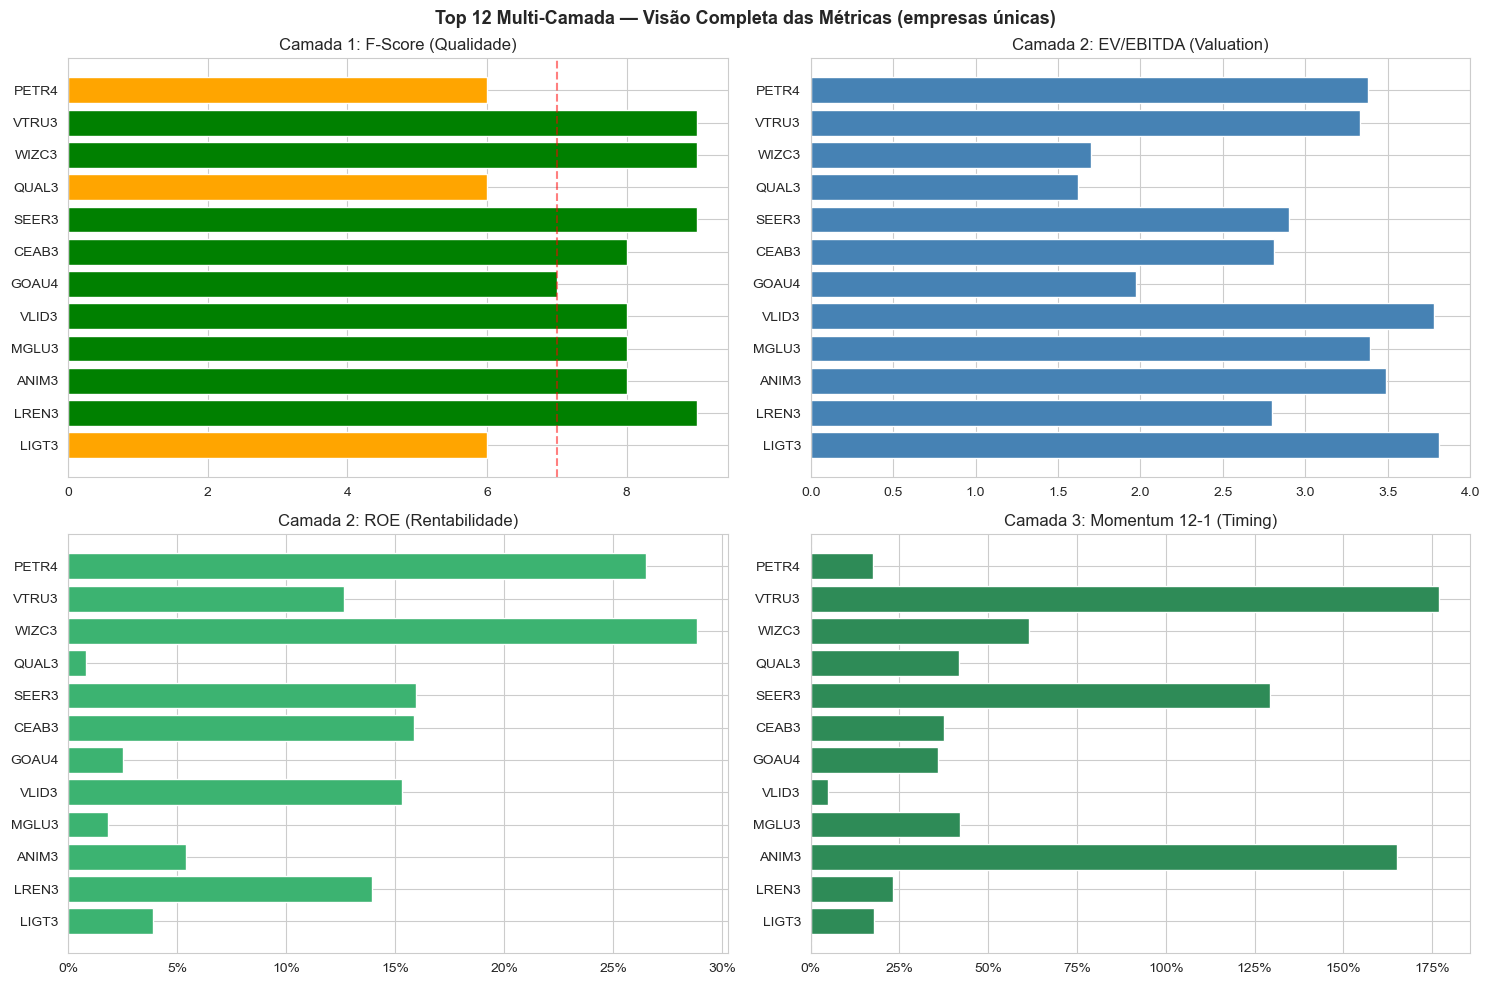

In [56]:
# top12 já foi definido pela célula de deduplicação (df_dedup.head(12))
# NÃO redefinir aqui — usar a variável deduplicada da Camada 4

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Top 12 Multi-Camada — Visão Completa das Métricas (empresas únicas)', fontsize=13, fontweight='bold')

# F-Score
colors_f = ['green' if s >= 7 else 'orange' for s in top12['F_SCORE']]
axes[0,0].barh(top12['Papel'][::-1], top12['F_SCORE'][::-1], color=colors_f[::-1])
axes[0,0].set_title('Camada 1: F-Score (Qualidade)')
axes[0,0].axvline(7, color='red', linestyle='--', alpha=0.5)

# EV/EBITDA
axes[0,1].barh(top12['Papel'][::-1], top12['EV/EBITDA'][::-1], color='steelblue')
axes[0,1].set_title('Camada 2: EV/EBITDA (Valuation)')

# ROE
axes[1,0].barh(top12['Papel'][::-1], top12['ROE'][::-1], color='mediumseagreen')
axes[1,0].set_title('Camada 2: ROE (Rentabilidade)')
axes[1,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))

# Momentum
colors_m = ['seagreen' if m > 0 else 'tomato' for m in top12['Momentum']]
axes[1,1].barh(top12['Papel'][::-1], top12['Momentum'][::-1], color=colors_m[::-1])
axes[1,1].set_title('Camada 3: Momentum 12-1 (Timing)')
axes[1,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
axes[1,1].axvline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## CAMADA 5 — Otimização Combinatória de Markowitz

Com o universo deduplicado garantindo empresas únicas, testamos **todas as combinações possíveis de 4 ativos**. 
Para cada combinação, o otimizador não-linear *SciPy/SLSQP* resolve os pesos que maximizam o **Índice de Sharpe** usando 5 anos de covariância histórica.

### Restrições de Peso (Constraints)
Para evitar que o otimizador gere carteiras com alocacao **0% em algum ativo** (o que equivale a ter 3 ativos de fato), impomos:
- **Mínimo por ativo: 5%** — todo ativo contribui de forma real
- **Máximo por ativo: 80%** — evita concentração excessiva em um único papel
- **Soma total: 100%** — restrição clássica de Markowitz
É selecionada apenas a combinação que produz **o maior Índice de Sharpe** com todos os 4 ativos tendo peso efetivo.


In [57]:
tickers_top = [t + '.SA' for t in top12['Papel'].tolist()]
rf = 0.1075

precos_5a = yf.download(tickers_top, start='2021-03-26', end='2026-03-26', progress=False)['Close']
precos_5a = precos_5a.dropna(axis=1, thresh=int(len(precos_5a)*0.8)).ffill().dropna()
tickers_v = precos_5a.columns.tolist()

ret_d = precos_5a.pct_change().dropna()
mu = ret_d.mean() * 252
cov = ret_d.cov() * 252

def neg_sharpe(w, mu, cov, rf):
    r = np.dot(w, mu); v = np.sqrt(w @ cov @ w)
    return -(r - rf)/v if v > 0 else 0

best_s, best_c, best_w = -np.inf, None, None
resultados_log = []

# Limites: mínimo 5% e máximo 80% por ativo
# Isso evita o problema de peso = 0% (ativo fantasma na carteira)
MIN_PESO, MAX_PESO = 0.05, 0.80

for comb in combinations(tickers_v, 4):
    mu_c = mu[list(comb)].values
    cov_c = cov.loc[list(comb), list(comb)].values
    res = minimize(neg_sharpe, [0.25]*4, args=(mu_c, cov_c, rf),
                   method='SLSQP', bounds=[(MIN_PESO, MAX_PESO)]*4,
                   constraints={'type':'eq','fun':lambda w: w.sum()-1})
    if not res.success:
        continue
    w_opt = res.x
    # Garantia extra: pula combinações onde algum ativo ficou abaixo de 2%
    if np.any(w_opt < 0.02):
        continue
    sh = -res.fun
    r_opt = np.dot(w_opt, mu_c)
    v_opt = np.sqrt(w_opt @ cov_c @ w_opt)
    resultados_log.append({'comb':comb,'sharpe':sh,'ret':r_opt,'vol':v_opt,'pesos':w_opt})
    if sh > best_s:
        best_s = sh; best_c = list(comb); best_w = w_opt

mu_f = mu[best_c].values
cov_f = cov.loc[best_c, best_c].values
ret_f = np.dot(best_w, mu_f)
vol_f = np.sqrt(best_w @ cov_f @ best_w)

print('='*60)
print('CARTEIRA FINAL — ESTRATÉGIA MULTI-CAMADA')
print('='*60)
for t, w in zip(best_c, best_w):
    papel = t.replace('.SA','')
    mom = df_final[df_final['Papel']==papel]['Momentum'].values
    ev  = df_final[df_final['Papel']==papel]['EV/EBITDA'].values
    print(f'  {papel}: {w*100:.2f}%  | EV/EBITDA={ev[0]:.1f}x | Momentum={mom[0]:+.1%}')
print(f'\n  Retorno Esperado : {ret_f*100:.2f}% a.a.')
print(f'  Volatilidade     : {vol_f*100:.2f}% a.a.')
print(f'  Índice de Sharpe : {best_s:.4f}')
print(f'  Prêmio vs. CDI   : {(ret_f - rf)*100:.2f}% a.a.')

CARTEIRA FINAL — ESTRATÉGIA MULTI-CAMADA
  CEAB3: 5.00%  | EV/EBITDA=2.8x | Momentum=+37.4%
  PETR4: 76.38%  | EV/EBITDA=3.4x | Momentum=+17.5%
  VLID3: 13.62%  | EV/EBITDA=3.8x | Momentum=+4.8%
  WIZC3: 5.00%  | EV/EBITDA=1.7x | Momentum=+61.4%

  Retorno Esperado : 40.96% a.a.
  Volatilidade     : 27.55% a.a.
  Índice de Sharpe : 1.0966
  Prêmio vs. CDI   : 30.21% a.a.


---
## Visualização Final: Fronteira Eficiente + Distribuição de Sharpes

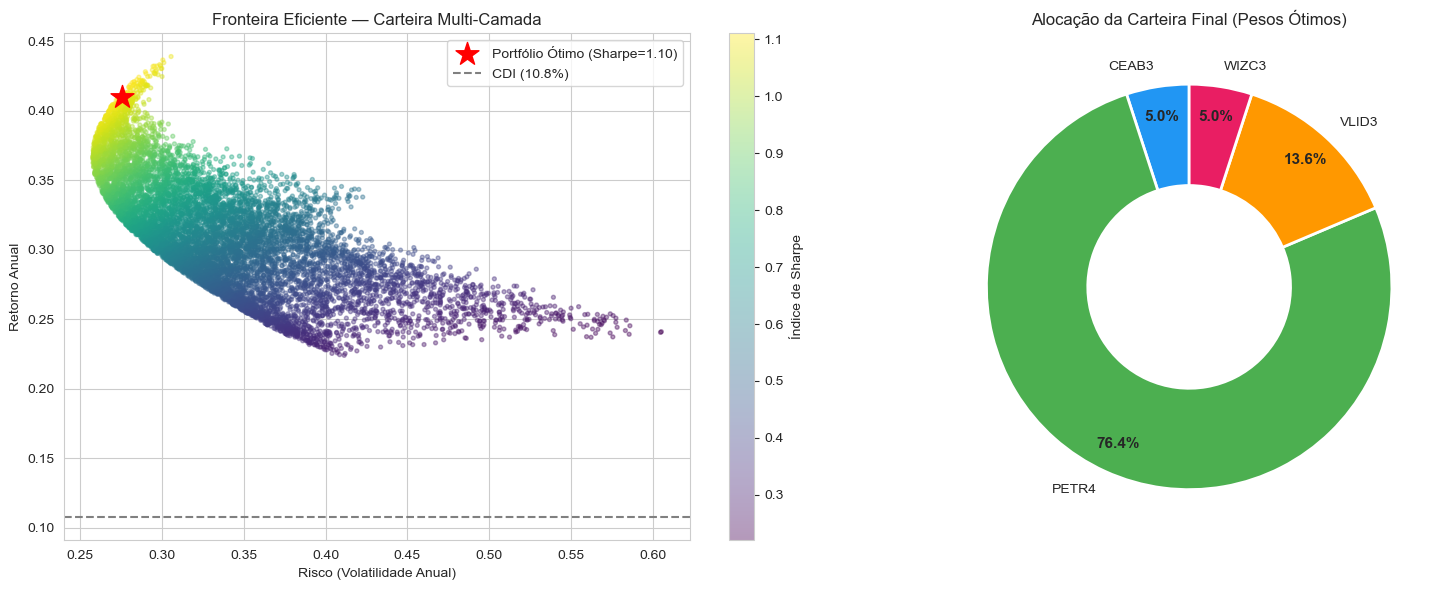

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fronteira Eficiente (Monte Carlo)
n_sim = 10000
rets, vols, sharpes = [], [], []
for _ in range(n_sim):
    w = np.random.dirichlet(np.ones(4))
    r, v = np.dot(w, mu_f), np.sqrt(w @ cov_f @ w)
    rets.append(r); vols.append(v); sharpes.append((r-rf)/v)

sc = axes[0].scatter(vols, rets, c=sharpes, cmap='viridis', s=8, alpha=0.4)
fig.colorbar(sc, ax=axes[0], label='Índice de Sharpe')
axes[0].scatter(vol_f, ret_f, marker='*', color='red', s=300, zorder=5,
               label=f'Portfólio Ótimo (Sharpe={best_s:.2f})')
axes[0].axhline(rf, color='gray', linestyle='--', label=f'CDI ({rf*100:.1f}%)')
axes[0].set_xlabel('Risco (Volatilidade Anual)')
axes[0].set_ylabel('Retorno Anual')
axes[0].set_title('Fronteira Eficiente — Carteira Multi-Camada')
axes[0].legend()

# Alocação por pizza
labels = [t.replace('.SA','') for t in best_c]
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63']
wedges, texts, autotexts = axes[1].pie(
    best_w, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.85,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[1].set_title('Alocação da Carteira Final (Pesos Ótimos)')

plt.tight_layout()
plt.show()

---
## Indicadores Fundamentalistas para o Relatório Técnico (Edital)

In [59]:
papeis_f = [t.replace('.SA','') for t in best_c]
df_ind = df_final[df_final['Papel'].isin(papeis_f)][
    ['Papel','F_SCORE','ROE','EV/EBITDA','P/VP','Dív.Brut/ Patrim.','Momentum']
].copy()
df_ind.columns = ['Ativo','F-Score','ROE (Rentabilidade)','EV/EBITDA (Valuation)','P/VP (Valuation)','Dív/PL (Endividamento)','Momentum 12M']
df_ind['ROE (Rentabilidade)'] = df_ind['ROE (Rentabilidade)'].map('{:.1%}'.format)
df_ind['Momentum 12M'] = df_ind['Momentum 12M'].map('{:+.1%}'.format)
display(df_ind.reset_index(drop=True))

print('\n==> Esses indicadores atendem DIRETAMENTE as 3 exigências do Edital:')
print('  ✓ Rentabilidade: ROE')
print('  ✓ Valuation    : EV/EBITDA + P/VP')
print('  ✓ Endividamento: Dívida Bruta / PL')

,Ativo,F-Score,ROE (Rentabilidade),EV/EBITDA (Valuation),P/VP (Valuation),Dív/PL (Endividamento),Momentum 12M
0,PETR4,6,26.5%,3.38,1.49,0.92,+17.5%
1,WIZC3,9,28.8%,1.70,1.99,0.56,+61.4%
2,CEAB3,8,15.8%,2.81,1.01,0.26,+37.4%
3,VLID3,8,15.3%,3.78,0.97,0.46,+4.8%



==> Esses indicadores atendem DIRETAMENTE as 3 exigências do Edital:
  ✓ Rentabilidade: ROE
  ✓ Valuation    : EV/EBITDA + P/VP
  ✓ Endividamento: Dívida Bruta / PL


---
## Conclusão: Por que esta é a Estratégia Recomendada?

A abordagem Multi-Camada supera cada estratégia individual porque:

1. **Abrangência:** Não depende de um único fator (ex: apenas P/L ou apenas ROE). Avalia qualidade, preço, momentum e risco simultaneamente.
2. **Cobertura Total:** Varre toda a B3 sem viés humano de seleção.
3. **Robustez Acadêmica:** Baseia-se em Piotroski (2000), Fama-French (2015), Jegadeesh & Titman (1993) e Markowitz (1952) — quatro pilares consolidados da literatura de finanças, todos alinhados à ementa do PPGOLD.
4. **Adequação ao Objetivo:** A competição dura meses (curto prazo). O Momentum garante timing correto; o F-Score garante solidez; o EV/EBITDA garante não pagar caro; o Markowitz garante a melhor combinação e alocação possível de exatamente 4 ativos.
